In [1]:
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import cv2
# import the necessary packages
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

# from keras.models import Sequential
# from keras.layers import Dense
from sklearn.preprocessing import StandardScaler
# from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import time
from math import sqrt

from plot_keras_history import show_history, plot_history

def get_encoding(series):
    #getting our classes
    array = series.to_numpy().reshape(-1,1)
    encoder = OneHotEncoder().fit(array)
    return encoder.transform(array).toarray(), encoder

def setup_keras_model(model, layers):
    for layer in layers:
        model.add(layer)
    
    print(model.summary())


def rmse(x,y):
    return sqrt(mean_squared_error(x,y))

    
def update_metrics(metric_df,df_test, preds, targets_str, metrics, model_name, input_features=None):    
    
    metric_df.loc[model_name, "input_features"] = input_features
    human_rows = df_test["class"] == "Pedestrian"
    hdf = df_test[human_rows]
    human_preds = [pred[human_rows] for pred in preds]
    
    #evaluate the targets
    for i, s in enumerate(targets_str):
        target = df_test[s]
        
        print(metrics[i](preds[i], target))
        metric = metrics[i](preds[i], target)
        metric_df.loc[model_name, f"{s}_{metrics[i].__name__}_total"] = metric
        
        #predict error for human targets only
        target = hdf[s]
        metric = metrics[i](human_preds[i], target)
        metric_df.loc[model_name, f"{s}_{metrics[i].__name__}_human"] = metric  
    

def save_model(model, model_dir, model_name):
    model_json = model.to_json()
    with open(f"{model_dir}/{model_name}.json", "w") as json_file:
        json_file.write(model_json)

    model.save_weights(f"{model_dir}/{model_name}.h5")
    print("Saved model to disk")



# update_metrics(metric_df, df_test["dist_feet"], df_test, "foo")

# Initiazling GPU

In [2]:
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

    except RuntimeError as e:
        print(e)
        
gpus

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# Sequential Generator
Needed cause the just loading all the images into ram overloads it and crashes jupyter.

In [3]:
#used because too many images
class My_Custom_Generator(tf.keras.utils.Sequence) :
  
  def __init__(self, image_filenames, labels, batch_size, img_dir):
    self.image_filenames = image_filenames
    self.labels = labels
    self.batch_size = batch_size
    self.img_dir = img_dir
    
  def __len__(self):
    return (np.ceil(len(self.image_filenames) / float(self.batch_size))).astype(int)
  
  
  def __getitem__(self, idx) :
    batch_x = self.image_filenames[idx * self.batch_size : (idx+1) * self.batch_size]
    batch_y = self.labels[idx * self.batch_size : (idx+1) * self.batch_size]
    return np.array([
            cv2.imread(img_dir + str(file_name))
               for file_name in batch_x])/255.0, np.array(batch_y)

# Functional API Generator

In [4]:
#used because too many images
class functional_api_generator(tf.keras.utils.Sequence):
  def __init__(self, df: pd.DataFrame, filenames: pd.Series, input_features: {str: [str],},
               output_features: {str: [str],}, batch_size: int, img_dir: str):
    self.df = df
    #encoders
    self.encoders = {}
    
    self.input_features = self.parse_features(input_features)
    self.output_features = self.parse_features(output_features)
    
    
        
    #filenames
    self.image_filenames = filenames
    
    #miscelaneous
    self.batch_size = batch_size
    self.img_dir = img_dir
    


    
  def __len__(self):
    return (np.ceil(len(self.image_filenames) / float(self.batch_size))).astype(int)
  
  
  def __getitem__(self, idx):
    

    start = idx * self.batch_size
    stop = (idx+1) * self.batch_size

    
    input_batch = {key: value[start:stop] for key, value in self.input_features.items()}
    output_batch = {key: value[start:stop] for key, value in self.output_features.items()}
    
    
    input_batch["img"] = np.array([cv2.imread(img_dir + str(file_name)) 
                                    for file_name in self.image_filenames[start:stop]])
    return input_batch, output_batch

  def parse_series(self, series):
    return get_encoding(series)[0] if series.dtype == object else series.values.reshape(-1,1)

  def parse_dataframe(self, df):
    values = []
    for key in df.columns:
        series = self.parse_series(df[key])
        values.append(series)
    
    return np.hstack(values)
    


  def parse_features(self, features):     
    features_w_data = {}
    for layer_key, df_key in features.items():
        data = self.df[df_key]
        
        if isinstance(data, pd.DataFrame):
            features_w_data[layer_key] = self.parse_dataframe(data)
                        
        elif isinstance(data, pd.Series):
            features_w_data[layer_key] = self.parse_series(data)
    
        
    return features_w_data

# Loading and Setting up DataFrames

In [5]:
#set up some directory names
global_dirname = "/home/jack/Desktop/code/projects/deloitte/cv_distance_estimation"
data_dir = f"{global_dirname}/data"
img_dir = f"/home/jack/Desktop/code/projects/deloitte/cv_distance_estimation/data/training/image_2_bounding/"
model_dir = f"{global_dirname}/models/"

#load data
df = pd.read_csv(f"{data_dir}/labels.csv")

df_train, df_test = (pd.read_csv(f"{data_dir}/train.csv"), pd.read_csv(f"{data_dir}/test.csv"))

df_train.reset_index(inplace=True)
df_test.reset_index(inplace=True)

img_metric_df = pd.DataFrame()

metric_df = pd.read_csv(f"{data_dir}/metrics/metric_df_bb_only.csv", index_col=0)

# Training Parameters

In [6]:
#choosing how many rows to train with
# n = 300
n = df_train.shape[0]

df_train = df_train.head(n)
df_test = df_test.head(n)

epochs = 10
verbose = 2
batch_size = 10

# train_class, class_encoder = get_encoding(df_train["class"])
train_class, class_encoder = get_encoding(df_train["class"])
test_class, class_encoder = get_encoding(df_test["class"])

class_shape_train = train_class[0].shape
class_shape_test = test_class[0].shape



#angle output encodings
# train_angle = get_encoding(df_train.angle_discrete)[0]
train_angle, angle_encoder = get_encoding(df_train.angle_discrete)
test_angle, class_encoder = get_encoding(df_test.angle_discrete)

angle_shape_train = train_angle[0].shape
angle_shape_test = test_angle[0].shape

angle_shape = train_class[0].shape


print(class_shape_train, class_shape_test)
print(angle_shape_train, angle_shape_test)

(8,) (8,)
(8,) (8,)


# Setting up batch generators for images

In [7]:
#initializing generators
my_training_batch_generator = My_Custom_Generator(df_train["filename_bb"],
                                                  df_train["dist_feet"], batch_size, img_dir)

my_testing_batch_generator = My_Custom_Generator(df_test["filename_bb"],
                                                 df_test["dist_feet"], batch_size, img_dir)

# Get model input shape

In [8]:
#setting up image directroy where the images will be coming from
file = f"{img_dir}/0.png"

image_shape = cv2.imread(file).shape

# Image with Bounding Box Only Training

In [9]:
#Model pathing and file names
model_name = "img_w_bb_only"

#_________________________________________Model Training
model = keras.models.Sequential()


layers = [keras.layers.Conv2D(500, kernel_size=3, activation="relu", input_shape=image_shape),
         keras.layers.AveragePooling2D(),
         keras.layers.Conv2D(250, kernel_size=3, activation="relu"),
         keras.layers.AveragePooling2D(),
         keras.layers.Flatten(),
         keras.layers.Dense(100, activation="relu"),
         keras.layers.Dense(32, activation="relu"),
         keras.layers.Dense(1)]


setup_keras_model(model, layers)


model.compile(loss='mean_squared_error', optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001, decay=0.00001),         )
history = model.fit(my_training_batch_generator, batch_size=32, epochs=epochs, verbose=2)


save_model(model, f"{model_dir}/models", model_name)


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 92, 308, 500)      14000     
_________________________________________________________________
average_pooling2d (AveragePo (None, 46, 154, 500)      0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 44, 152, 250)      1125250   
_________________________________________________________________
average_pooling2d_1 (Average (None, 22, 76, 250)       0         
_________________________________________________________________
flatten (Flatten)            (None, 418000)            0         
_________________________________________________________________
dense (Dense)                (None, 100)               41800100  
_________________________________________________________________
dense_1 (Dense)              (None, 32)                3

(<Figure size 360x360 with 1 Axes>,
 <AxesSubplot:title={'center':'Loss'}, xlabel='Epochs', ylabel='Loss'>)

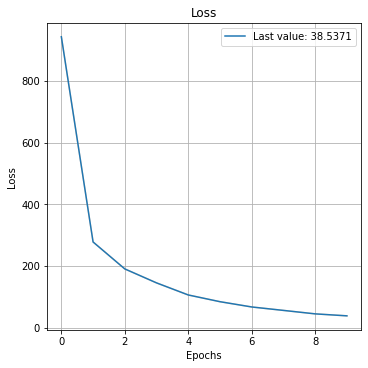

In [10]:
plot_history(history, path=f"{global_dirname}/results_history/{model_name}")

In [11]:
pred = model.predict(my_testing_batch_generator)
model_name = "img_w_bb_only"


print("foo")

update_metrics(img_metric_df,
               df_test, 
               [pred],
               ["dist_feet"],
               [rmse],
               model_name)

img_metric_df.to_csv(f"{data_dir}/metrics/model_metrics.csv")

img_metric_df

foo
8.983222726663696


,input_features,dist_feet_rmse_total,dist_feet_rmse_human
img_w_bb_only,NaN,8.983223,6.666739


# Image with Bounding Box and Class

## Getting inputs

In [12]:
#class encodings
# train_class, class_encoder = get_encoding(df_train["class"])
train_class, class_encoder = get_encoding(df_train["class"])
class_shape = test_class[0].shape

#angle output encodings
# train_angle = get_encoding(df_train.angle_discrete)[0]
test_angle, angle_encoder = get_encoding(df_train.angle_discrete)
angle_shape = test_angle[0].shape

#images already done
img_input = keras.Input(shape=image_shape, name="img")

#class input
class_input = keras.Input(shape=class_shape, name="class")

print(class_shape, angle_shape)

(8,) (8,)


# Generators for Distance only model

In [13]:

input_features_dist = {"class": ["class"]}
output_features_dist = {"distance": ["dist_feet"]}



train_generator_dist = functional_api_generator(df_train, df_train["filename_bb"], input_features_dist,
                                                 output_features_dist, batch_size, img_dir)

test_generator_dist = functional_api_generator(df_test, df_test["filename_bb"], input_features_dist,
                                                 output_features_dist, batch_size, img_dir)

# generators for angle discrete modesl

In [14]:
input_features_angle_discrete = {"class": ["class"]}
output_features_angle_discrete = {"distance": ["dist_feet"], "angle": ["angle_discrete"]}

train_generator_angle = functional_api_generator(df_test, df_test["filename_bb"], input_features_angle_discrete,
                                                 output_features_angle_discrete, batch_size, img_dir)

test_generator_angle = functional_api_generator(df_test, df_test["filename_bb"], input_features_angle_discrete,
                                                 output_features_angle_discrete, batch_size, img_dir)


# Generators for trig angle model


In [15]:
input_features_angle_trig = {"class": ["class"]}
output_features_angle_trig = {"distance": ["dist_feet"], "trig_angle": ["sin_angle", "cos_angle"]}

train_generator_trig = functional_api_generator(df_test, df_test["filename_bb"], input_features_angle_trig,
                                                 output_features_angle_trig, batch_size, img_dir)

test_generator_trig = functional_api_generator(df_test, df_test["filename_bb"], input_features_angle_trig,
                                                 output_features_angle_trig, batch_size, img_dir)

## Setup Model

In [16]:
#image layers
img_layer = keras.layers.Conv2D(500, kernel_size=3, activation="relu")(img_input)
img_layer = keras.layers.AveragePooling2D()(img_layer)
img_layer = keras.layers.Conv2D(250, kernel_size=3, activation="relu")(img_layer)
img_layer = keras.layers.AveragePooling2D()(img_layer)
img_layer = keras.layers.Flatten()(img_layer)

#class layers
class_layer = keras.layers.Dense(30, kernel_initializer='normal', activation='relu')(class_input)
class_layer = keras.layers.Dense(15, kernel_initializer='normal', activation='relu')(class_layer)
class_layer = keras.layers.Dense(8, kernel_initializer='normal', activation='relu')(class_layer)

#concatanate the two layers
combined_layer = keras.layers.concatenate([img_layer, class_layer])

combined_layer = keras.layers.Dense(100, activation="relu")(combined_layer)
combined_layer = keras.layers.Dense(32, activation="relu")(combined_layer)

#output layers
dist_layer = keras.layers.Dense(1, name="distance")(combined_layer)
angle_layer = keras.layers.Dense(angle_shape[0], name="angle")(combined_layer)
trig_angle_layer = keras.layers.Dense(2, name="trig_angle")(combined_layer)

# Distance Model Training and Evaluation

In [17]:
#defining full model
dist_model = keras.Model(
    inputs=[img_input, class_input],
    outputs=[dist_layer],
)



In [18]:
class_shape

(8,)

Epoch 1/10
3043/3043 - 209s - loss: 640.6761
Epoch 2/10
3043/3043 - 207s - loss: 217.0821
Epoch 3/10
3043/3043 - 208s - loss: 134.7287
Epoch 4/10
3043/3043 - 208s - loss: 93.2794
Epoch 5/10
3043/3043 - 208s - loss: 65.9777
Epoch 6/10
3043/3043 - 215s - loss: 51.8022
Epoch 7/10
3043/3043 - 208s - loss: 42.3313
Epoch 8/10
3043/3043 - 208s - loss: 33.5696
Epoch 9/10
3043/3043 - 208s - loss: 27.8652
Epoch 10/10
3043/3043 - 208s - loss: 23.9340
Saved model to disk


(<Figure size 360x360 with 1 Axes>,
 <AxesSubplot:title={'center':'Loss'}, xlabel='Epochs', ylabel='Loss'>)

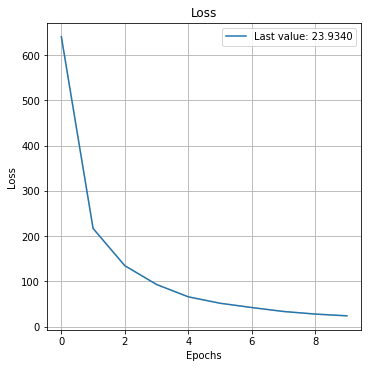

In [19]:
model_name = "img_bb+class~dist_feet"

keras.utils.plot_model(dist_model, f"{global_dirname}/models/diagrams/{model_name}.png", show_shapes=True)

dist_model.compile(loss={"distance": "mean_squared_error"},
                  optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001, decay=0.00001))

dist_model_history = dist_model.fit(train_generator_dist,
                    batch_size=32,epochs=10, verbose=2)

save_model(dist_model, model_dir, model_name)
plot_history(dist_model_history, path=f"{global_dirname}/results_history/{model_name}")

In [20]:
pred = dist_model.predict(test_generator_dist)

model_name = "img_bb+class~dist_feet"

update_metrics(img_metric_df,
               df_test, 
               [pred],
               ["dist_feet"],
               [rmse],
               model_name)

img_metric_df.to_csv(f"{data_dir}/metrics/model_metrics.csv")

8.568188528613772


In [21]:
img_metric_df

,input_features,dist_feet_rmse_total,dist_feet_rmse_human
img_w_bb_only,NaN,8.983223,6.666739
img_bb+class~dist_feet,NaN,8.568189,5.928725


# Angle Discrete Training and Evaluation

In [22]:
dist_and_angle_model = keras.Model(
    inputs=[img_input, class_input],
    outputs=[dist_layer, angle_layer]
)



Epoch 1/10
1015/1015 - 71s - loss: 92.1744 - distance_loss: 84.6286 - angle_loss: 7.5458
Epoch 2/10
1015/1015 - 70s - loss: 48.5767 - distance_loss: 41.9715 - angle_loss: 6.6051
Epoch 3/10
1015/1015 - 70s - loss: 35.8320 - distance_loss: 29.9473 - angle_loss: 5.8848
Epoch 4/10
1015/1015 - 70s - loss: 29.2523 - distance_loss: 23.0481 - angle_loss: 6.2043
Epoch 5/10
1015/1015 - 70s - loss: 27.2015 - distance_loss: 21.5129 - angle_loss: 5.6886
Epoch 6/10
1015/1015 - 70s - loss: 27.2029 - distance_loss: 21.7555 - angle_loss: 5.4474
Epoch 7/10
1015/1015 - 70s - loss: 25.8164 - distance_loss: 20.4342 - angle_loss: 5.3821
Epoch 8/10
1015/1015 - 70s - loss: 23.7576 - distance_loss: 18.1784 - angle_loss: 5.5791
Epoch 9/10
1015/1015 - 70s - loss: 21.2513 - distance_loss: 15.7746 - angle_loss: 5.4766
Epoch 10/10
1015/1015 - 70s - loss: 21.1491 - distance_loss: 15.6479 - angle_loss: 5.5011
Saved model to disk


(<Figure size 1080x360 with 3 Axes>,
 array([<AxesSubplot:title={'center':'Loss'}, xlabel='Epochs', ylabel='Loss'>,
        <AxesSubplot:title={'center':'Distance loss'}, xlabel='Epochs', ylabel='Distance loss'>,
        <AxesSubplot:title={'center':'Angle loss'}, xlabel='Epochs', ylabel='Angle loss'>],
       dtype=object))

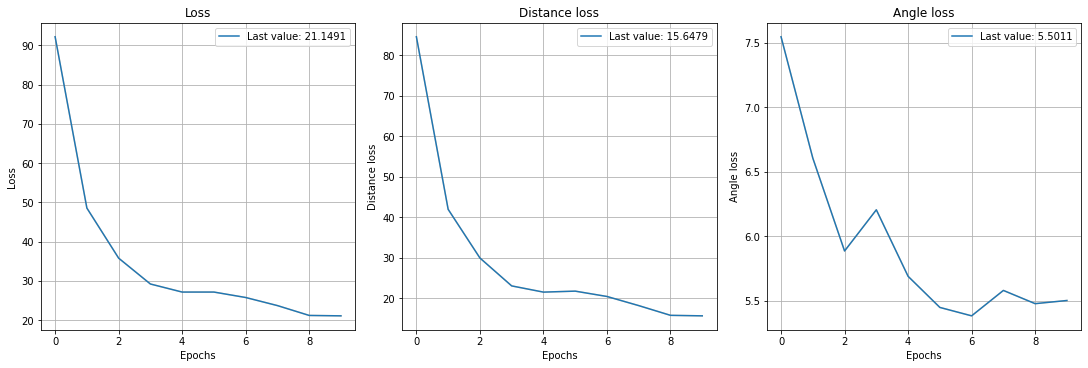

In [23]:
model_name = "img_bb+class~dist_feet+angle_discrete"

keras.utils.plot_model(dist_and_angle_model, f"{global_dirname}/models/diagrams/{model_name}.png", show_shapes=True)

#compile the model
dist_and_angle_model.compile(loss={"distance": "mean_squared_error", "angle": "categorical_crossentropy"},
                  optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001, decay=0.00001))

#train the model
dist_and_angle_model_history = dist_and_angle_model.fit(train_generator_angle,
                    batch_size=32,epochs=10, verbose=2)

#save the model
save_model(dist_and_angle_model, model_dir, model_name)

#save loss graphs
plot_history(dist_and_angle_model_history, path=f"{global_dirname}/results_history/{model_name}")

In [24]:
from sklearn.metrics import accuracy_score
model_name = "img_bb+class~dist_feet+angle_discrete"

dist_pred, angle_pred = dist_and_angle_model.predict(test_generator_dist)

angle_pred = angle_encoder.inverse_transform(angle_pred)

update_metrics(img_metric_df, df_test, 
               [dist_pred, angle_pred],
               ["dist_feet", "angle_discrete"],
               [rmse, accuracy_score],
               model_name)

img_metric_df.to_csv(f"{data_dir}/metrics/model_metrics.csv")
img_metric_df

3.5063881078871195
0.10529429162969535


,input_features,dist_feet_rmse_total,dist_feet_rmse_human,angle_discrete_accuracy_score_total,angle_discrete_accuracy_score_human
img_w_bb_only,NaN,8.983223,6.666739,NaN,NaN
img_bb+class~dist_feet,NaN,8.568189,5.928725,NaN,NaN
img_bb+class~dist_feet+angle_discrete,NaN,3.506388,2.337986,0.105294,0.108108


# Trig Model Training and Evaluation

In [25]:
dist_and_trig_model = keras.Model(
    inputs=[img_input, class_input],
    outputs=[dist_layer, trig_angle_layer]
)

In [26]:
model_name = "img_bb+class~dist_feet+(cos_angle + sin_angle)"

keras.utils.plot_model(dist_and_trig_model, f"{global_dirname}/models/diagrams/{model_name}.png", show_shapes=True)

dist_and_trig_model.compile(loss={"distance": 'mean_squared_error', "trig_angle": "cosine_similarity"}, 
                   optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001, decay=0.00001))

#train the model
dist_and_trig_model_history = dist_and_trig_model.fit(train_generator_trig,
                    batch_size=32,epochs=10, verbose=2)



Epoch 1/10
1015/1015 - 70s - loss: 15.7052 - distance_loss: 15.8295 - trig_angle_loss: -1.2421e-01
Epoch 2/10
1015/1015 - 70s - loss: 17.9880 - distance_loss: 18.1169 - trig_angle_loss: -1.2894e-01
Epoch 3/10
1015/1015 - 70s - loss: 15.4402 - distance_loss: 15.5732 - trig_angle_loss: -1.3309e-01
Epoch 4/10
1015/1015 - 70s - loss: 13.5938 - distance_loss: 13.7300 - trig_angle_loss: -1.3620e-01
Epoch 5/10
1015/1015 - 70s - loss: 10.9990 - distance_loss: 11.1385 - trig_angle_loss: -1.3943e-01
Epoch 6/10
1015/1015 - 70s - loss: 11.4935 - distance_loss: 11.6354 - trig_angle_loss: -1.4183e-01
Epoch 7/10
1015/1015 - 70s - loss: 13.2351 - distance_loss: 13.3812 - trig_angle_loss: -1.4607e-01
Epoch 8/10
1015/1015 - 69s - loss: 11.2271 - distance_loss: 11.3749 - trig_angle_loss: -1.4775e-01
Epoch 9/10
1015/1015 - 67s - loss: 9.8723 - distance_loss: 10.0241 - trig_angle_loss: -1.5176e-01
Epoch 10/10
1015/1015 - 67s - loss: 10.0389 - distance_loss: 10.1928 - trig_angle_loss: -1.5396e-01


Saved model to disk


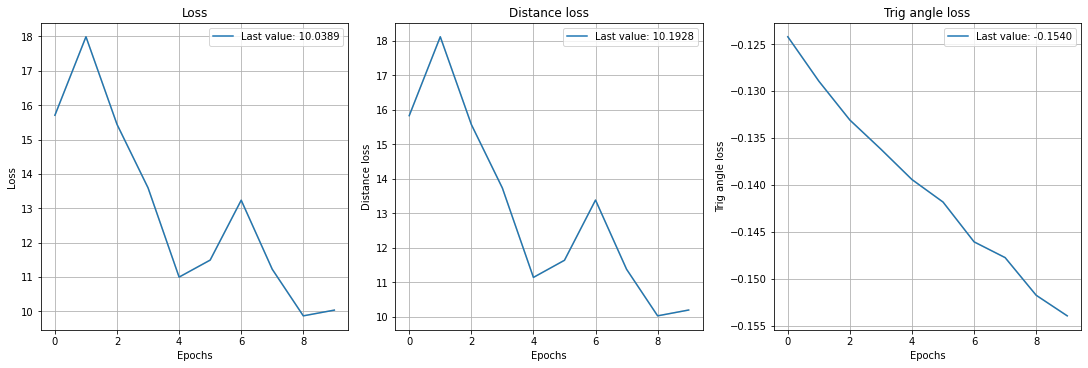

In [27]:
plot_history(dist_and_trig_model_history, path=f"{global_dirname}/results_history/{model_name}")

save_model(dist_and_trig_model, model_dir, model_name)

In [28]:

def aggregate_cos_distance(pred, target, aggregator=np.mean):
    return aggregator(np.matrix.diagonal(cosine_distances(pred, target)))
    

In [29]:
dist_pred, trig_angle = dist_and_trig_model.predict(test_generator_angle)

from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_distances

print(trig_angle)
model_name = "img_bb+class~dist_feet+(cos_angle + sin_angle)"

update_metrics(img_metric_df, df_test, 
               (dist_pred, trig_angle),
               ("dist_feet", ["cos_angle", "sin_angle"]),
               (rmse, aggregate_cos_distance),
               "image+class_find~dist+cos+sin")

img_metric_df.to_csv(f"{data_dir}/metrics/model_metrics.csv")

img_metric_df

[[-287.76245 -284.0019 ]
 [ -81.5579  -243.14972]
 [-179.47333 -191.51988]
 ...
 [-362.31964 -328.7827 ]
 [-152.53156 -289.96594]
 [-214.09593 -261.24216]]
2.6996355298695627
0.8935282836752657


,input_features,dist_feet_rmse_total,dist_feet_rmse_human,angle_discrete_accuracy_score_total,angle_discrete_accuracy_score_human,"['cos_angle', 'sin_angle']_aggregate_cos_distance_total","['cos_angle', 'sin_angle']_aggregate_cos_distance_human"
img_w_bb_only,NaN,8.983223,6.666739,NaN,NaN,NaN,NaN
img_bb+class~dist_feet,NaN,8.568189,5.928725,NaN,NaN,NaN,NaN
img_bb+class~dist_feet+angle_discrete,NaN,3.506388,2.337986,0.105294,0.108108,NaN,NaN
image+class_find~dist+cos+sin,NaN,2.699636,1.749320,NaN,NaN,0.893528,1.065057
